This notebook is a mirror of `visualise_embedding.ipynb`, except that we analyse the embedding space of the pretrained Inception-v3 model used to compute FID. Here, we can compare how well the model separates bad generations from true data.

See `visualise_embedding.ipynb` for more details and comments.

In [1]:
import os

# Change this variable if the root folder name has been changed
root_dir = "nvae-shape-encoding"
current_dir = os.getcwd()

if not current_dir.endswith(root_dir):
    %cd ../..

assert os.getcwd().endswith(root_dir)

/Users/freddy/Desktop/Unshared/nvae-shape-encoding


/Users/freddy/Desktop/Unshared/nvae-shape-encoding/venv/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import lightning as L
import torch

from const import SEED
from data_modules.acdc import ACDCMaskDataModule
from utils.utils import setup_device

# Setup device
device = setup_device()
print(f"Device: {device}")

# Seed
L.seed_everything(SEED)

# Load data
data_module = ACDCMaskDataModule(batch_size=20)

# Reseed after preprocessing data
L.seed_everything(SEED)

/Users/freddy/Desktop/Unshared/nvae-shape-encoding/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 1969


Device: mps
Preprocessed training data found. Loading...
Preprocessed test data found. Loading...


Seed set to 1969


1969

In [3]:
data_train = data_module.data_train.masks
data_test = data_module.data_test.masks

print(data_train.shape)
print(data_test.shape)

torch.Size([1711, 4, 128, 128])
torch.Size([1076, 4, 128, 128])


In [4]:
import torch.nn as nn
from torchvision.models import inception_v3

# Load inception model
model = inception_v3(weights="DEFAULT", transform_input=False).to(device)

model.fc = nn.Identity()
model.eval()

print("# Parameters")
print(sum(p.numel() for p in model.parameters()))

# Parameters
25112264


In [5]:
from utils.eval import encode_embeddings

# Extract features for train images
train_feats = encode_embeddings(data_train, model, device, resnet=False)
print(train_feats.shape)

# Extract features for test images
test_feats = encode_embeddings(data_test, model, device, resnet=False)
print(test_feats.shape)

torch.Size([1711, 2048])
torch.Size([1076, 2048])


In [6]:
from arch.nvae.nvae import NVAE
from arch.vae.vae import VAE
from utils.utils import discretise

# eeee
assert train_feats.shape[0] < test_feats.shape[0]
num_samples = test_feats.shape[0]

def generate_data_vae(model: VAE) -> torch.Tensor:
    # Sample from latent space
    z = torch.randn(num_samples, model.hparams.latent_dim).to(device)

    with torch.no_grad():
        model.eval()
        model.to(device)
        
        # Generate segmentation maps from latent variables
        x_fake_logits: torch.Tensor = model.decoder(z)

    return x_fake_logits

def generate_data_nvae(model: NVAE) -> torch.Tensor:
    # Sample from latent space
    with torch.no_grad():
        model.eval()
        model.to(device)
        
        x_fake = model.decoder.generate(num_samples, device)
        feats_fake = model.conditional_coder(x_fake)

    return feats_fake

autoencoder_model_path = "logs/vae_acdc/info-vae/ld-8-beta-0-gamma-200/checkpoints/epoch=48-step=5243.ckpt"
autoencoder_model = VAE.load_from_checkpoint(autoencoder_model_path)

good_logits = generate_data_vae(autoencoder_model)

autoencoder_model_path = "logs/vae_acdc/info-vae/ld-8-beta-0-gamma-5/checkpoints/epoch=47-step=5136.ckpt"
autoencoder_model = VAE.load_from_checkpoint(autoencoder_model_path)

bad_logits = generate_data_vae(autoencoder_model)

good_fake_data = discretise(good_logits)
bad_fake_data = discretise(bad_logits)

good_feats = encode_embeddings(good_fake_data, model, device)
bad_feats = encode_embeddings(bad_fake_data, model, device)

print(good_feats.shape)
print(bad_feats.shape)

torch.Size([1076, 2048])
torch.Size([1076, 2048])


In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(train_feats)

print(f"Explained variance: {pca.explained_variance_ratio_}")
print(f"Sum: {pca.explained_variance_ratio_.sum()}")

train_feats_reduced = pca.transform(train_feats)
test_feats_reduced = pca.transform(test_feats)
good_feats_reduced = pca.transform(good_feats)
bad_feats_reduced = pca.transform(bad_feats)

print(train_feats_reduced.shape)
print(test_feats_reduced.shape)
print(good_feats_reduced.shape)
print(bad_feats_reduced.shape)

Explained variance: [0.55685893 0.12690425]
Sum: 0.6837631744953583
(1711, 2)
(1076, 2)
(1076, 2)
(1076, 2)


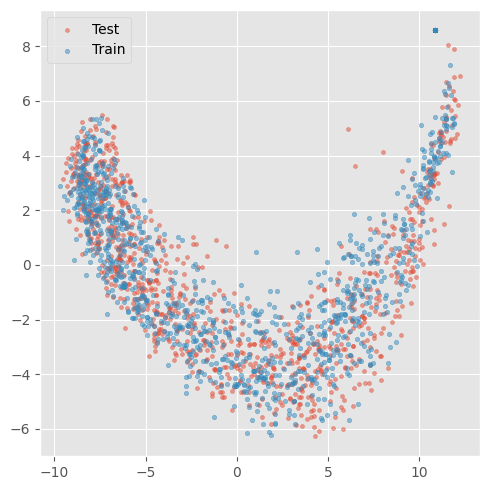

In [8]:
from matplotlib import pyplot as plt

plt.style.use("ggplot")

plt.figure(figsize=(5, 5))
plt.scatter(test_feats_reduced[:, 0], test_feats_reduced[:, 1], alpha=0.5, s=8, label="Test")
plt.scatter(train_feats_reduced[:num_samples, 0], train_feats_reduced[:num_samples, 1], alpha=0.5, s=10, label="Train")

plt.tight_layout()
plt.legend()
plt.show()

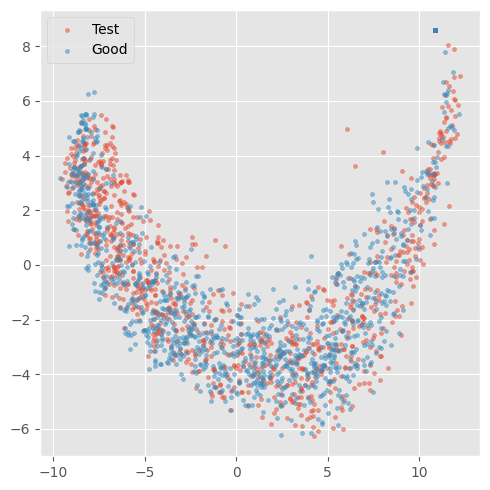

In [11]:
plt.figure(figsize=(5, 5))
plt.scatter(test_feats_reduced[:, 0], test_feats_reduced[:, 1], alpha=0.5, s=8, label="Test")
plt.scatter(good_feats_reduced[:, 0], good_feats_reduced[:, 1], alpha=0.5, s=8, label="Good")

plt.tight_layout()
plt.legend()
plt.show()

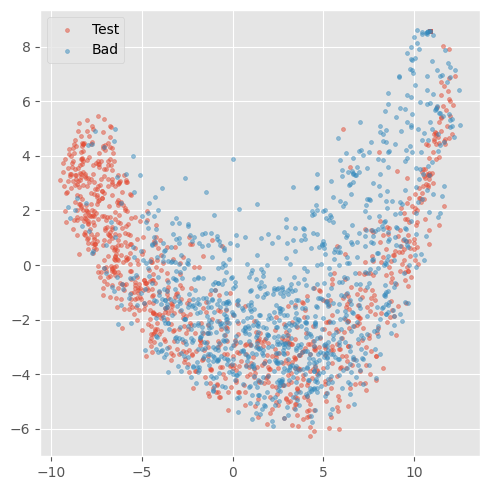

In [12]:
plt.figure(figsize=(5, 5))
plt.scatter(test_feats_reduced[:, 0], test_feats_reduced[:, 1], alpha=0.5, s=8, label="Test")
plt.scatter(bad_feats_reduced[:, 0], bad_feats_reduced[:, 1], alpha=0.5, s=8, label="Bad")

plt.tight_layout()
plt.legend()
plt.show()